In [1]:
import os
import torch
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn.functional as F
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

from pathlib import Path
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import pairwise_distances, confusion_matrix
from sklearn.decomposition import PCA

from lib.data.utils import Color
from lib.data.datasets import (
    ColoredMNISTDataset,
    get_ColoredMNISTDataset_dataloader
)
from lib.models import (
    CVAE, CVAEFilm,
    AEModelConfig
)
from lib.analysis import tg_mds
from lib.plotting import fig_to_rgba
from lib import filepaths

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
@torch.no_grad()
def get_reconstruction(cvae, pixel_values, label_id, feature_id, p, verbose=False):
    cvae.eval()

    pixel_values = pixel_values.to(device)
    sem_embed = cvae.sem_embeddings(torch.tensor([label_id], device=device)).view(-1, *cvae.cond_hidden_shape)
    feat_embed = cvae.feat_embeddings(torch.tensor([feature_id], device=device)).view(-1, *cvae.cond_hidden_shape)
    mu, logvar = cvae.encode(pixel_values[None])
    z = cvae._reparameterize(mu, logvar)

    z = mu*(1-p)
    rec = cvae.decode(z, sem_embed, feat_embed)
    rec = torch.clip(rec, 0, 1)

    if verbose:
        return rec[0].cpu(), z.cpu()
    else:
        return rec[0].cpu()

In [3]:
color_codes = [Color.RED, Color.GREEN, Color.CYAN, Color.YELLOW, Color.MAGENTA]

test_dataset = ColoredMNISTDataset(color_codes=color_codes, resize=32, train=False)

test_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=128,
    dataset=test_dataset,
    drop_last=True, shuffle=False
)

In [4]:
ckpt = torch.load("resources/ckpt_cvae_film_basic.pt", weights_only=False)

cvae = CVAEFilm(
    config=ckpt["config"],
    **ckpt["kwargs"]
) 
cvae.load_state_dict(ckpt["state_dict"])
cvae.to(device)
cvae.eval()
cvae.show_number_of_parameters()

0.561M / 0.561M


In [5]:
n = 3
df = test_dataset.data_table.copy()
labels = [3, 9, 5]
features = [0,4,1]
idx = np.hstack([
    df.query(f"label=={labels[i]} and color_id=={features[i]}").sample(
        3, 
        replace=False,
        random_state=42
    ).index 
    for i in range(n)
])

ps = [0., 0.5, 1]

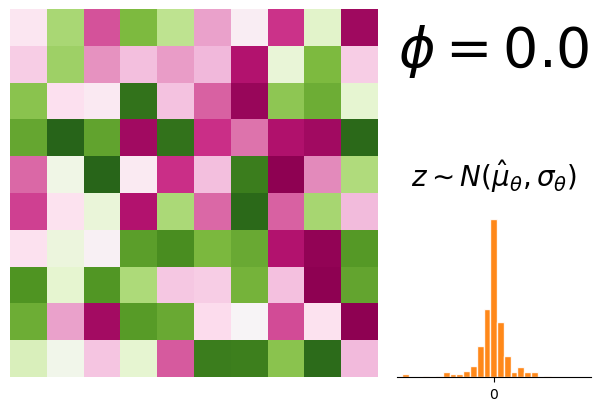

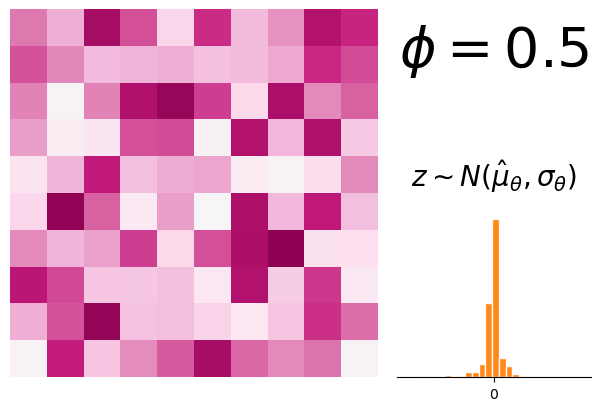

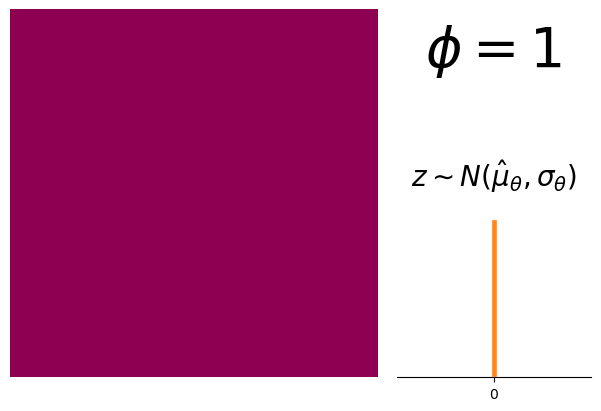

In [9]:
top_images = []

pixel_values, label_id, feature_id = test_dataset[idx[-1]]

for i in range(len(ps)):

    x_rec, z = get_reconstruction(cvae, pixel_values, label_id, feature_id, p=ps[i], verbose=True)

    fig = plt.figure(figsize=(6,4), constrained_layout=True)
    gs = fig.add_gridspec(
        nrows=2,
        ncols=3,
        height_ratios=[1,2]
    )

    ax = fig.add_subplot(gs[:2, :2])
    x = np.random.rand(10,10)
    ax.imshow(x*(1 - ps[i]), vmin=0, vmax=1, cmap="PiYG")
    ax.axis("off")

    ax = fig.add_subplot(gs[1,2])
    ax.hist(z.numpy().flatten(), bins=int(1000/(i+1)), alpha=0.9, facecolor="#FF7B00", edgecolor="white")
    ax.set_xlim(-0.05,0.05)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks([0])
    ax.set_yticks([])

    ax = fig.add_subplot(gs[0,2])
    ax.text(0.5, 0.5, fr"$\phi={ps[i]}$", ha='center', va='center', fontsize=40)
    ax.text(
        0.5, -1,
        r"$ z \sim N(\hat \mu_{\theta}, \sigma_{\theta}) $",
        ha='center', va='center', fontsize=20
    )
    ax.axis("off")

    fig.savefig(f"visuals/gist-random_{i}.pdf")

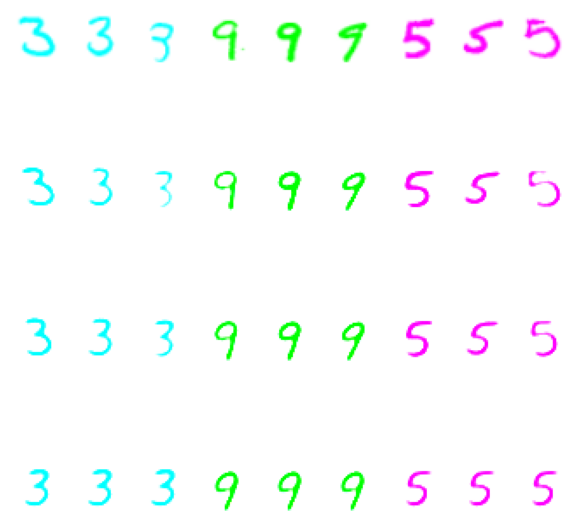

In [12]:
fig = plt.figure(figsize=(8.5,6), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=4,
    ncols=10,
    width_ratios=[5] + [1]*9,
    hspace=0
)

ax = fig.add_subplot(gs[0,0])
ax.set_visible(False)

for i in range(len(idx)):
    ax = fig.add_subplot(gs[0, i+1])

    pixel_values, label_id, feature_id = test_dataset[idx[i]]
    x_true = to_pil_image(1 - pixel_values)

    ax.imshow(x_true)
    ax.axis("off")

    for j, p in enumerate(ps):
        ax = fig.add_subplot(gs[j+1, i+1])

        x_rec = get_reconstruction(cvae, pixel_values, label_id, feature_id, p=p)
        x_rec = to_pil_image(1 - x_rec)

        ax.imshow(x_rec)
        ax.axis("off")

fig.savefig("visuals/gist_images.pdf", dpi=600)